<a href="https://colab.research.google.com/github/waheed-alam007/Data_analytics_Decodelabe/blob/main/data_analytics2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import joblib

joblib.dump(model, '/content/drive/MyDrive/model.pkl')

In [8]:
import pandas as pd
df = pd.read_excel("/content/Cleaned_Dataset.xlsx")
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,0,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [10]:
print("First 5 Rows:")

First 5 Rows:


In [11]:

display(df.head())



,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [12]:
print("\nDataset Info:")
df.info()




Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [13]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [14]:
print("===== BASIC STATISTICS =====")

print("Total Orders (Count):", df['OrderID'].count())

print("\nQuantity:")
print("Mean:", df['Quantity'].mean())
print("Median:", df['Quantity'].median())

print("\nUnit Price:")
print("Mean:", df['UnitPrice'].mean())
print("Median:", df['UnitPrice'].median())

print("\nTotal Price:")
print("Mean:", df['TotalPrice'].mean())
print("Median:", df['TotalPrice'].median())

===== BASIC STATISTICS =====
Total Orders (Count): 1200

Quantity:
Mean: 2.9458333333333333
Median: 3.0

Unit Price:
Mean: 356.41275
Median: 364.21

Total Price:
Mean: 1053.9683
Median: 823.615


In [15]:
df['Date'] = pd.to_datetime(df['Date'])

In [17]:
sales_trend = df.groupby('Date')['TotalPrice'].sum()
display(sales_trend.head(10))

,TotalPrice
Date,
2023-01-01,2021.11
2023-01-02,1323.55
2023-01-03,897.70
2023-01-04,3629.54
2023-01-05,3642.30
2023-01-06,1524.36
2023-01-07,2398.12
2023-01-08,2748.37
2023-01-10,996.28


In [18]:
product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

print("===== TOP PRODUCTS =====")
display(product_sales.head(10))

===== TOP PRODUCTS =====


,TotalPrice
Product,
Chair,195620.11
Printer,195612.61
Laptop,192126.56
Tablet,186568.95
Monitor,175651.41
Desk,167459.93
Phone,151722.39


In [19]:
payment_analysis = df['PaymentMethod'].value_counts()

print("===== PAYMENT METHOD DISTRIBUTION =====")
display(payment_analysis)

===== PAYMENT METHOD DISTRIBUTION =====


,count
PaymentMethod,
Online,258
Cash,246
Credit Card,234
Debit Card,232
Gift Card,230


In [20]:
coupon_usage = df['CouponCode'].value_counts()

print("===== COUPON USAGE =====")
display(coupon_usage.head())

===== COUPON USAGE =====


,count
CouponCode,
FREESHIP,313
0,309
WINTER15,292
SAVE10,286


In [21]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Quantity'] < (Q1 - 1.5 * IQR)) | (df['Quantity'] > (Q3 + 1.5 * IQR))]

print("===== OUTLIERS IN QUANTITY =====")
print("Number of Outliers:", len(outliers))
display(outliers.head())

===== OUTLIERS IN QUANTITY =====
Number of Outliers: 0


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


In [22]:
print("===== QUANTITY DISTRIBUTION =====")
display(df['Quantity'].value_counts())

===== QUANTITY DISTRIBUTION =====


,count
Quantity,
1,255
4,251
2,240
3,237
5,217


In [23]:
referral = df['ReferralSource'].value_counts()

print("===== REFERRAL SOURCE =====")
display(referral)

===== REFERRAL SOURCE =====


,count
ReferralSource,
Instagram,259
Email,250
Google,241
Facebook,228
Referral,222


In [24]:
print("===== KEY OBSERVATIONS =====")

print("1. Most orders contain small quantities (low number of items).")
print("2. A few products generate significantly higher revenue.")
print("3. Sales vary across different dates, showing trends.")
print("4. Some outliers exist in quantity, indicating unusually large orders.")
print("5. Majority of customers do not use coupon codes.")
print("6. Certain payment methods are used more frequently than others.")

===== KEY OBSERVATIONS =====
1. Most orders contain small quantities (low number of items).
2. A few products generate significantly higher revenue.
3. Sales vary across different dates, showing trends.
4. Some outliers exist in quantity, indicating unusually large orders.
5. Majority of customers do not use coupon codes.
6. Certain payment methods are used more frequently than others.


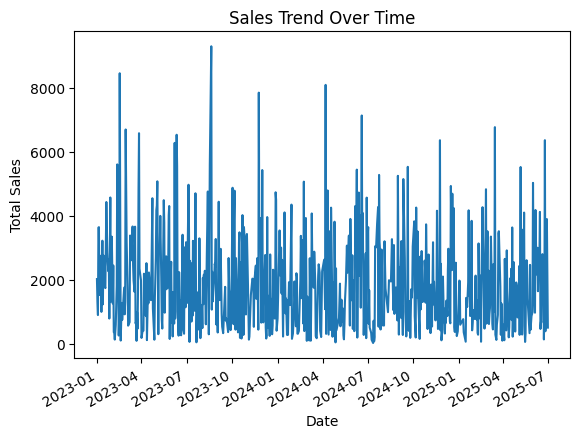

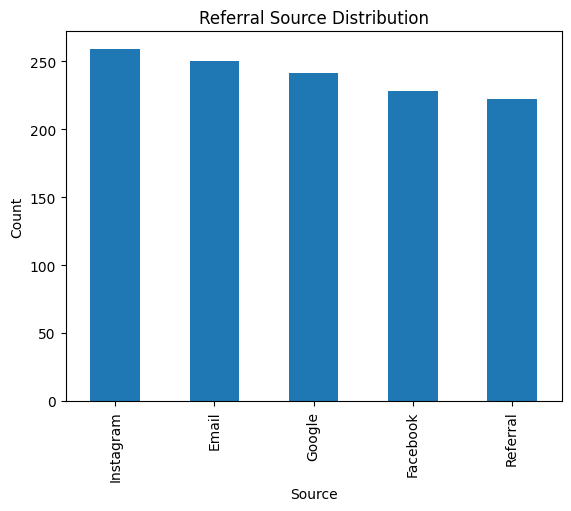

In [26]:
import matplotlib.pyplot as plt

# ===== SALES TREND (LINE CHART) =====
plt.figure()
sales_trend.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()


# ===== REFERRAL SOURCE =====
plt.figure()
df['ReferralSource'].value_counts().plot(kind='bar')
plt.title("Referral Source Distribution")
plt.xlabel("Source")
plt.ylabel("Count")
plt.show()

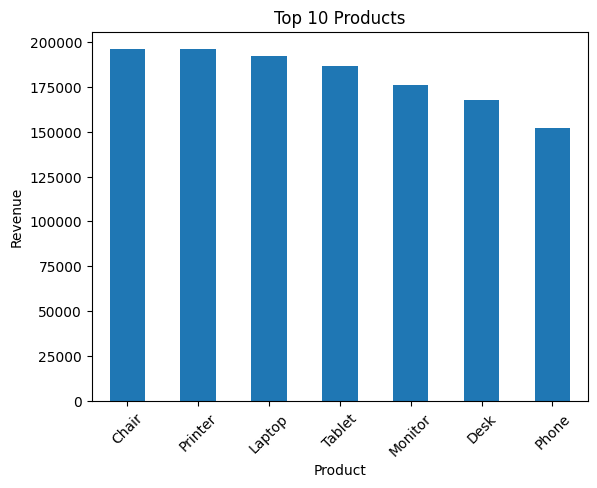

In [27]:

# ===== TOP PRODUCTS (BAR CHART) =====
plt.figure()
product_sales.head(10).plot(kind='bar')
plt.title("Top 10 Products")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()



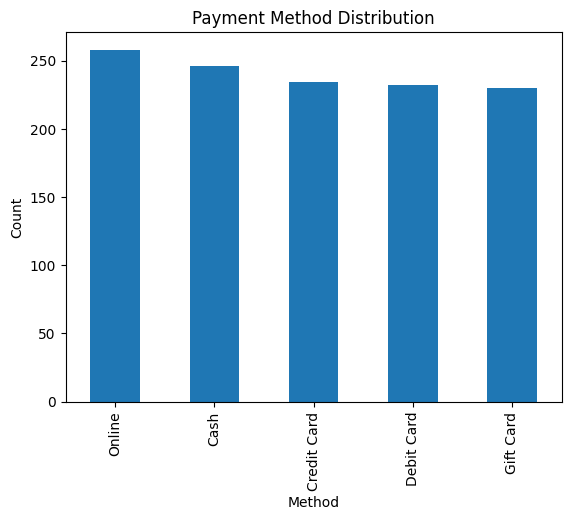

In [28]:

# ===== PAYMENT METHOD =====
plt.figure()
df['PaymentMethod'].value_counts().plot(kind='bar')
plt.title("Payment Method Distribution")
plt.xlabel("Method")
plt.ylabel("Count")
plt.show()


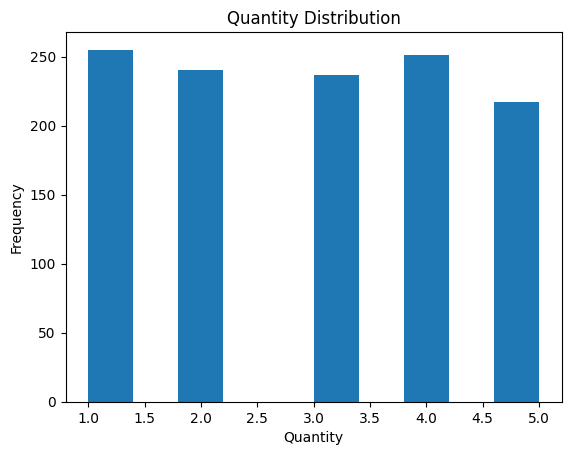

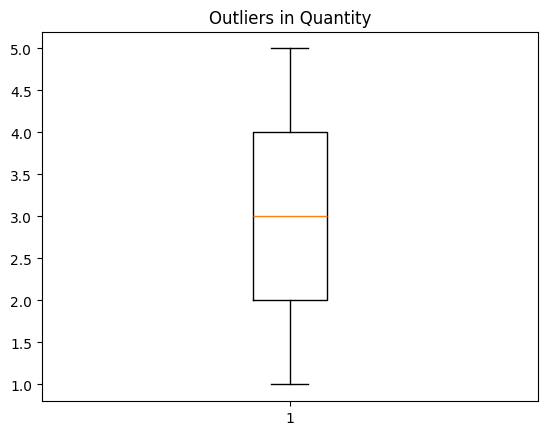

In [29]:

# ===== QUANTITY DISTRIBUTION =====
plt.figure()
plt.hist(df['Quantity'])
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

# ===== OUTLIER BOXPLOT =====
plt.figure()
plt.boxplot(df['Quantity'])
plt.title("Outliers in Quantity")
plt.show()

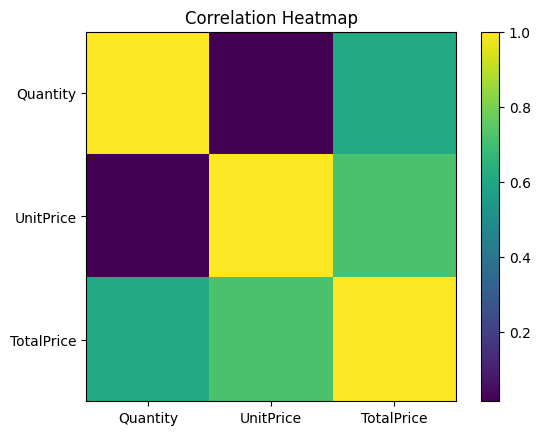

In [30]:
# ===== ADVANCED EDA =====
import matplotlib.pyplot as plt

# ===== CORRELATION HEATMAP =====
plt.figure()
corr = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()

plt.imshow(corr)
plt.title("Correlation Heatmap")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()


===== CORRELATION MATRIX =====
            Quantity  UnitPrice  TotalPrice
Quantity    1.000000   0.014553    0.615251
UnitPrice   0.014553   1.000000    0.717081
TotalPrice  0.615251   0.717081    1.000000

===== TOP 5 SALES DAYS =====
Date
2023-08-20    9290.49
2023-02-16    8448.00
2024-04-07    8085.26
2023-11-24    7842.55
2024-06-19    7129.53
Name: TotalPrice, dtype: float64


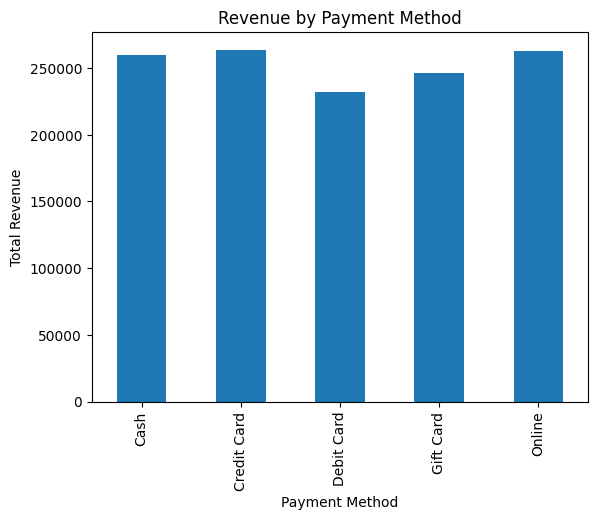

In [31]:
print("\n===== CORRELATION MATRIX =====")
print(corr)

# ===== TOP 5 REVENUE DAYS =====
top_days = sales_trend.sort_values(ascending=False).head(5)

print("\n===== TOP 5 SALES DAYS =====")
print(top_days)

# ===== SALES BY PAYMENT METHOD =====
payment_sales = df.groupby('PaymentMethod')['TotalPrice'].sum()

plt.figure()
payment_sales.plot(kind='bar')
plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.show()

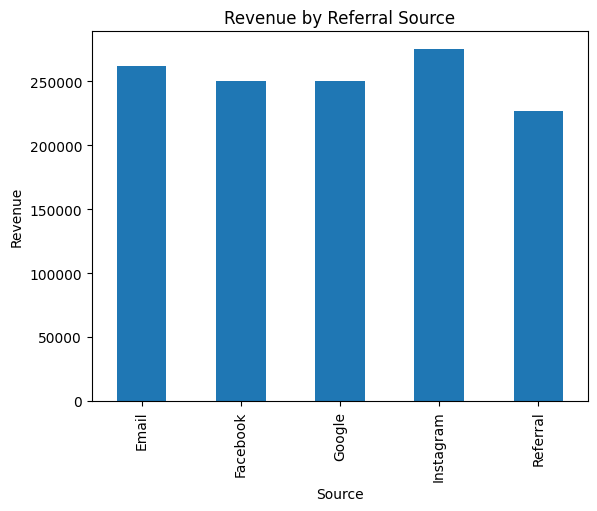

In [32]:
# ===== SALES BY REFERRAL SOURCE =====
ref_sales = df.groupby('ReferralSource')['TotalPrice'].sum()

plt.figure()
ref_sales.plot(kind='bar')
plt.title("Revenue by Referral Source")
plt.xlabel("Source")
plt.ylabel("Revenue")
plt.show()


In [33]:
# ===== ADVANCED OBSERVATIONS =====
print("\n===== ADVANCED INSIGHTS =====")
print("1. Strong correlation exists between Quantity and TotalPrice.")
print("2. Certain days generate peak revenue (top sales days identified).")
print("3. Some payment methods contribute more to total revenue.")
print("4. Referral sources impact revenue generation differently.")
print("5. Unit price has moderate influence on total revenue.")


===== ADVANCED INSIGHTS =====
1. Strong correlation exists between Quantity and TotalPrice.
2. Certain days generate peak revenue (top sales days identified).
3. Some payment methods contribute more to total revenue.
4. Referral sources impact revenue generation differently.
5. Unit price has moderate influence on total revenue.
